# Seção 3 — Integração com Python

Autor: Heleno Campos

Ultima atualização: 27/05/2026

**Banco de dados:** `dados/biblioteca.db`  
**Schema:**
- `livros(id, titulo, genero, ano)`
- `usuarios(id, nome, cidade)`
- `emprestimos(id, usuario_id, livro_id, data_emp, data_dev)`

---

## 1. Importações

In [12]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

DB = '../dados/biblioteca.db'

---
## 2. Conexão com sqlite3 e uso do cursor

O módulo `sqlite3` é nativo do Python — não precisa instalar nada.

- `conn` — objeto de conexão com o banco
- `cursor` — executa queries e retorna resultados
- `fetchone()` — retorna 1 linha
- `fetchall()` — retorna todas as linhas

In [13]:
conn = sqlite3.connect(DB)
cursor = conn.cursor()

# Contagem de registros em cada tabela
for tabela in ['livros', 'usuarios', 'emprestimos']:
    cursor.execute(f'SELECT COUNT(*) FROM {tabela}')
    total = cursor.fetchone()[0]
    print(f'{tabela:15s}: {total:>10,} linhas')

conn.close()

livros         :    100,000 linhas
usuarios       :     10,000 linhas
emprestimos    :    500,000 linhas


---
## 3. Queries parametrizadas — Segurança contra injeção SQL

**Nunca** construa queries com f-string a partir de entrada do usuário:  
```python
# ERRADO — vulnerável a SQL Injection
cursor.execute(f"SELECT * FROM livros WHERE genero = '{genero}'")
```

Use sempre o placeholder `?` e passe os valores como tupla:

In [14]:
genero  = 'Ficcao'
ano_min = 2000

conn = sqlite3.connect(DB)
cursor = conn.cursor()

cursor.execute("""
    SELECT id, titulo, ano
    FROM   livros
    WHERE  genero = ?
      AND  ano    > ?
    LIMIT  5
""", (genero, ano_min))

for row in cursor.fetchall():
    print(row)

conn.close()

(25, 'O Hobbit #275', 2022)
(28, 'Dom Casmurro #272', 2021)
(36, 'Vinte Mil Leguas Submarinas #739', 2018)
(59, 'O Cortico #553', 2023)
(65, 'A Metamorfose #197', 2007)


---
## 4. pandas — `read_sql_query`

A forma mais prática de trazer dados SQL para análise em Python.  
Use `with` para garantir que a conexão seja fechada automaticamente.

In [15]:
SQL = """
    SELECT id, titulo, genero, ano
    FROM   livros
    WHERE  ano > 2000
"""

with sqlite3.connect(DB) as conn:
    df = pd.read_sql_query(SQL, conn)

print(f'Shape: {df.shape}')
print()
print(df.dtypes)
print()
df.head()

Shape: (32034, 4)

id        int64
titulo      str
genero      str
ano       int64
dtype: object



,id,titulo,genero,ano
0,6,Hyperion #204,Filosofia,2019
1,12,Admiravel Mundo Novo #271,Biografia,2008
2,22,Grande Sertao Veredas #474,Romance,2021
3,25,O Hobbit #275,Ficcao,2022
4,26,Breve Historia do Tempo #736,Romance,2013


---
## 5. Análise com pandas

In [16]:
# Estatísticas gerais
df.describe()

,id,ano
count,32034.000000,32034.000000
mean,49939.082225,2012.530405
std,28890.571827,6.923896
min,6.000000,2001.000000
25%,24916.250000,2007.000000
50%,49646.500000,2013.000000
75%,74942.750000,2019.000000
max,99994.000000,2024.000000


In [17]:
# Filtrar livros recentes
recentes = df[df['ano'] >= 2010]
print(f'Livros publicados a partir de 2010: {len(recentes):,}')

Livros publicados a partir de 2010: 20,094


In [18]:
# Estatísticas por gênero
(
    df.groupby('genero')['ano']
      .agg(total='count', media_ano='mean', min_ano='min', max_ano='max')
      .sort_values('total', ascending=False)
)

,total,media_ano,min_ano,max_ano
genero,,,,
Ficcao,7156,2012.546814,2001,2024
Romance,6306,2012.437678,2001,2024
Historia,4493,2012.413532,2001,2024
Ciencia,3834,2012.609807,2001,2024
Biografia,3241,2012.632212,2001,2024
Filosofia,3179,2012.691412,2001,2024
Terror,2234,2012.575201,2001,2024
Policial,1591,2012.370836,2001,2024


---
## 6. Gráficos com matplotlib

> **Boa prática:** faça a agregação no banco (SQL), não no Python. Carregue apenas o resumo.

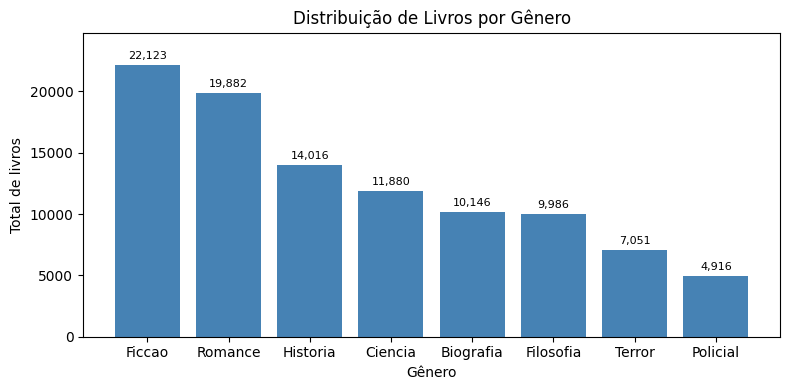

In [19]:
SQL_GENERO = """
    SELECT genero, COUNT(*) AS total
    FROM   livros
    GROUP  BY genero
    ORDER  BY total DESC
"""

with sqlite3.connect(DB) as conn:
    df_gen = pd.read_sql_query(SQL_GENERO, conn)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(df_gen['genero'], df_gen['total'], color='steelblue')
ax.bar_label(bars, fmt='{:,.0f}', padding=3, fontsize=8)
ax.set_xlabel('Gênero')
ax.set_ylabel('Total de livros')
ax.set_title('Distribuição de Livros por Gênero')
ax.set_ylim(0, df_gen['total'].max() * 1.12)
plt.tight_layout()
plt.savefig('../dados/livros_por_genero.png', dpi=150)
plt.show()

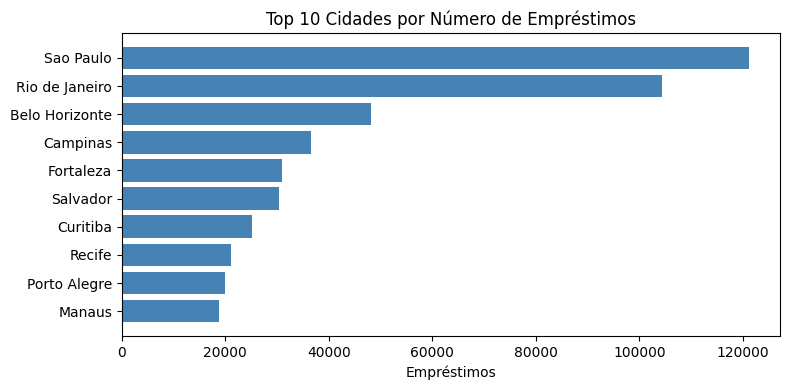

In [20]:
# Empréstimos por cidade (top 10)
SQL_CIDADE = """
    SELECT u.cidade, COUNT(*) AS emprestimos
    FROM   usuarios AS u
    JOIN   emprestimos e ON u.id = e.usuario_id
    GROUP  BY u.cidade
    ORDER  BY emprestimos DESC
    LIMIT  10
"""

with sqlite3.connect(DB) as conn:
    df_cid = pd.read_sql_query(SQL_CIDADE, conn)

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(df_cid['cidade'][::-1], df_cid['emprestimos'][::-1], color='steelblue')
ax.set_xlabel('Empréstimos')
ax.set_title('Top 10 Cidades por Número de Empréstimos')
plt.tight_layout()
plt.show()

---
## 7. Boas práticas: banco de dados grande

| Problema | Solução |
|---|---|
| Carregar tabela inteira | Filtrar com `WHERE` na query |
| `SELECT *` desnecessário | Selecionar só as colunas usadas |
| Filtrar/agregar no Python | Fazer no SQL antes de carregar |
| Conexão não fechada | Usar `with sqlite3.connect(...)` |
| Query desconhecida | Explorar com `LIMIT 100` primeiro |

In [21]:
# Exemplo: explorar antes de carregar tudo
with sqlite3.connect(DB) as conn:
    amostra = pd.read_sql_query("""
        SELECT id, titulo, genero, ano
        FROM   livros
        LIMIT  100
    """, conn)

print('Amostra (100 linhas):')
amostra.head()

Amostra (100 linhas):


,id,titulo,genero,ano
0,1,A Maquina do Tempo #115,Ficcao,1985
1,2,A Metamorfose #229,Ficcao,1963
2,3,Vinte Mil Leguas Submarinas #759,Terror,1961
3,4,Fahrenheit 451 #433,Ficcao,1961
4,5,O Cortico #239,Historia,1953


---
## 8. Pipeline completo: SQL → pandas → CSV

In [22]:
SQL_PIPELINE = """
    SELECT u.cidade,
           COUNT(*)          AS total_emp,
           COUNT(DISTINCT e.livro_id) AS livros_distintos
    FROM   usuarios AS u
    JOIN   emprestimos e ON u.id = e.usuario_id
    GROUP  BY u.cidade
    ORDER  BY total_emp DESC
"""

with sqlite3.connect(DB) as conn:
    resultado = pd.read_sql_query(SQL_PIPELINE, conn)

resultado.to_csv('../dados/emprestimos_por_cidade.csv', index=False)
print(f'{len(resultado)} cidades exportadas.')
resultado

15 cidades exportadas.


,cidade,total_emp,livros_distintos
0,Sao Paulo,121125,70244
1,Rio de Janeiro,104446,64649
2,Belo Horizonte,48094,38127
3,Campinas,36578,30614
4,Fortaleza,31004,26670
5,Salvador,30423,26160
6,Curitiba,25192,22306
7,Recife,21035,19002
8,Porto Alegre,20047,18155
9,Manaus,18713,17133
